<a href="https://colab.research.google.com/github/hsandmann/biblio/blob/main/material/handouts/regressao-do-zero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão linear, do zero

**Machine Learning · Insper**

Este roteiro percorre um caminho só, sem atalho:

1. escrever o modelo em forma matricial, $\hat{y} = Xw$;
2. tentar a saída óbvia — inverter \(X\) — e ver, rodando, por que ela não existe;
3. chegar às equações normais, resolvendo uma delas no papel;
4. medir onde essa solução quebra quando o número de atributos cresce;
5. implementar o gradiente descendente à mão e conferir que ele chega ao mesmo lugar.

Nenhuma célula depende de biblioteca de ML. Só `numpy` para as contas de matriz e
`matplotlib` para ver. Rode as células em ordem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Cinco pontos

Números pequenos de propósito: tudo o que vier a seguir pode ser conferido à mão.

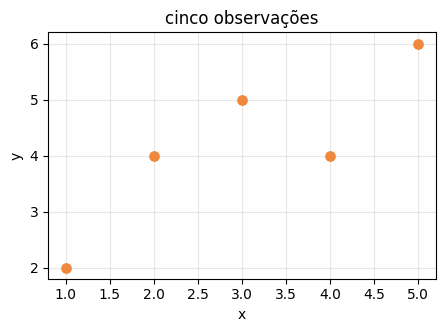

x = [1. 2. 3. 4. 5.]
y = [2. 4. 5. 4. 6.]


In [2]:
x = np.array([1., 2., 3., 4., 5.])
y = np.array([2., 4., 5., 4., 6.])

plt.figure(figsize=(5,3.2))
plt.scatter(x, y, s=45, color='#f0883e', zorder=3)
plt.xlabel('x'); plt.ylabel('y'); plt.grid(alpha=.3)
plt.title('cinco observações'); plt.show()

print("x =", x)
print("y =", y)

## 2. A forma matricial

O modelo é $\hat{y}_i = w_0 + w_1 x_i$. Empilhando as observações e **absorvendo o
intercepto como uma coluna de 1s**, isso vira uma única multiplicação de matrizes:

$$
\hat{y} = Xw,
\qquad
X = \begin{pmatrix} 1 & x_1 \\ \vdots & \vdots \\ 1 & x_n \end{pmatrix},
\qquad
w = \begin{pmatrix} w_0 \\ w_1 \end{pmatrix}
$$

A coluna de 1s não é truque de notação: é o que faz o intercepto ser tratado como
qualquer outro peso.

In [3]:
X = np.column_stack([np.ones_like(x), x])
print("X =")
print(X)
print("\nforma de X:", X.shape, " ->", X.shape[0], "observações,", X.shape[1], "parâmetros")

X =
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]

forma de X: (5, 2)  -> 5 observações, 2 parâmetros


## 3. A tentativa óbvia: $w = X^{-1}y$

Se $\hat{y} = Xw$, o reflexo é isolar $w$ invertendo $X$. Rode e veja o que acontece.

In [4]:
try:
    w = np.linalg.inv(X) @ y
    print("w =", w)
except np.linalg.LinAlgError as erro:
    print("LinAlgError:", erro)

LinAlgError: Last 2 dimensions of the array must be square


### Primeiro obstáculo: $X$ não é quadrada

`inv` só aceita matriz quadrada, e $X$ é $5 \times 2$. No caso geral ela é $n \times d$ com $n \gg d$ — milhares de linhas, poucas colunas.

### Segundo obstáculo, o que realmente importa

Mesmo ignorando o formato: **não existe solução exata**. O sistema $y = Xw$ tem 5 equações e 2 incógnitas — é *sobredeterminado*. Um $w$ exato só existiria se $y$ estivesse no espaço gerado pelas colunas de $X$.

O posto responde isso. Se acrescentar $y$ a $X$ **aumenta** o posto, é porque $y$ aponta para uma direção que as colunas de $X$ não alcançam.

In [5]:
posto_X   = np.linalg.matrix_rank(X)
posto_aug = np.linalg.matrix_rank(np.column_stack([X, y]))

print("posto(X)      =", posto_X)
print("posto([X | y]) =", posto_aug)
print()
if posto_aug > posto_X:
    print("y NÃO está no espaço-coluna de X.")
    print("=> nenhum w satisfaz Xw = y exatamente.")
else:
    print("y está no espaço-coluna: existe solução exata.")

posto(X)      = 2
posto([X | y]) = 3

y NÃO está no espaço-coluna de X.
=> nenhum w satisfaz Xw = y exatamente.


Isso não é azar deste conjunto: é a situação normal. Se existisse $w$ exato, todos os resíduos seriam zero e a reta passaria por todos os pontos. Com dados ruidosos isso não acontece — **e é justamente por isso que a regressão existe**.

## 4. O que fazemos no lugar

Como $y$ está fora de alcance, buscamos o ponto alcançável **mais próximo** dele: minimizar $\lVert y - Xw \rVert^2$. Igualando o gradiente a zero chega-se às **equações normais**:

$$X^\top X\, w = X^\top y$$

O truque está no formato: $X^\top X$ é $d \times d$ — **quadrada** — e invertível sempre que $X$ tem posto-coluna cheio. Nunca invertemos $X$; invertemos $X^\top X$.

In [6]:
XtX = X.T @ X
Xty = X.T @ y

print("XᵀX =");  print(XtX);  print("forma:", XtX.shape, "-> quadrada")
print("\nXᵀy =", Xty)

w = np.linalg.solve(XtX, Xty)     # resolve o sistema; NÃO usa inv()
print("\nw =", w)
print(f"reta ajustada:  ŷ = {w[0]:.1f} + {w[1]:.1f}·x")

XᵀX =
[[ 5. 15.]
 [15. 55.]]
forma: (2, 2) -> quadrada

Xᵀy = [21. 71.]

w = [1.8 0.8]
reta ajustada:  ŷ = 1.8 + 0.8·x


### Conferindo no papel

Com estes cinco pontos o sistema é pequeno o bastante para resolver à mão:

$$
X^\top X = \begin{pmatrix} 5 & 15 \\ 15 & 55 \end{pmatrix},
\qquad
X^\top y = \begin{pmatrix} 21 \\ 71 \end{pmatrix}
$$

$$
\begin{cases} 5w_0 + 15w_1 = 21 \\ 15w_0 + 55w_1 = 71 \end{cases}
$$

- Da primeira,

    $$\displaystyle w_0 = \frac{21 - 15w_1}{5}$$.

- Substituindo na segunda:

    \begin{align}
    \displaystyle 15 \left( \frac{21 - 15w_1}{5} \right) + 55w_1 & = 71 \\
    \displaystyle 3 \left( 21 - 15w_1 \right) + 55w_1 & = 71 \\
    63 - 45w_1 + 55w_1 & = 71 \\
    10w_1 & = 8 \\
    w_1 & = 0{,}8
    \end{align}
    
    portanto,

    \begin{align}
    \displaystyle w_0 &= \frac{21 - 15w_1}{5} \\
    &= 1{,}8
    \end{align}

    ao final:

    $\mathbf{w_1 = 0{,}8}$ e $\mathbf{w_0 = 1{,}8}$

Confira contra a saída da célula acima.

In [9]:
yhat = X @ w
resid = y - yhat

print("ŷ =", yhat)
print("e =", resid)
print()
print("Σe      =", round(resid.sum(), 12) + 0.0)
print("Σe·x    =", round((resid * x).sum(), 12) + 0.0)
print("Xᵀe     =", (X.T @ resid).round(12) + 0.0)
print()
print("Os dois zeros acima SÃO as equações normais, escritas por extenso:")
print("uma por parâmetro. O resíduo é ortogonal a cada coluna de X.")

ŷ = [2.6 3.4 4.2 5.  5.8]
e = [-0.6  0.6  0.8 -1.   0.2]

Σe      = 0.0
Σe·x    = 0.0
Xᵀe     = [0. 0.]

Os dois zeros acima SÃO as equações normais, escritas por extenso:
uma por parâmetro. O resíduo é ortogonal a cada coluna de X.


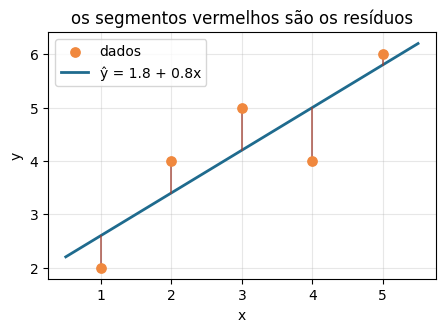

In [8]:
plt.figure(figsize=(5,3.2))
plt.scatter(x, y, s=45, color='#f0883e', zorder=3, label='dados')
xs = np.linspace(0.5, 5.5, 50)
plt.plot(xs, w[0] + w[1]*xs, color='#1F6B8E', lw=2, label=f'ŷ = {w[0]:.1f} + {w[1]:.1f}x')
for xi, yi, yh in zip(x, y, yhat):
    plt.plot([xi, xi], [yi, yh], color='#9E3B2E', lw=1.2, alpha=.8)
plt.legend(); plt.grid(alpha=.3); plt.xlabel('x'); plt.ylabel('y')
plt.title('os segmentos vermelhos são os resíduos'); plt.show()

## 5. Onde a forma fechada quebra

A fórmula funciona. A pergunta é **até quando**.

Duas coisas crescem com o número de atributos $d$:

- **tempo**: resolver o sistema custa $O(d^3)$;
- **memória**: $X^\top X$ tem $d \times d$ elementos, independentemente de quantas observações você tenha.

Meça o tempo você mesmo. Se o custo é cúbico, dobrar $d$ deveria multiplicar o tempo por $2^3 = 8$. Nos tamanhos pequenos você verá menos que isso — o custo fixo de chamar a rotina e o paralelismo interno da BLAS (Basic Linear Algebra Subprograms) ainda pesam mais que a conta. A razão sobe em direção a 8 conforme $d$ cresce.

In [10]:
rng = np.random.default_rng(0)
print(f"{'d':>6} {'tempo':>10} {'razão vs d/2':>14}")
anterior = None
for d in [250, 500, 1000, 2000]:
    A = rng.standard_normal((d, d)); A = A @ A.T + d*np.eye(d)   # simétrica positiva-definida
    b = rng.standard_normal(d)
    t = min(( (lambda t0: (np.linalg.solve(A, b), time.perf_counter()-t0)[1])(time.perf_counter())
              for _ in range(3) ))
    razao = f"{t/anterior:.1f}×" if anterior else "—"
    print(f"{d:>6} {t:>9.4f}s {razao:>14}")
    anterior = t

     d      tempo   razão vs d/2
   250    0.0014s              —
   500    0.0082s           6.0×
  1000    0.0333s           4.1×
  2000    0.2341s           7.0×


O tempo é ruim, mas ainda administrável. O que **impede de vez** é a memória: $X^\top X$ é $d \times d$, e isso não depende de $n$.

In [11]:
print("memória necessária só para GUARDAR XᵀX (float64):\n")
for d in [1_000, 10_000, 50_000, 100_000]:
    gb = d*d*8 / 1e9
    veredito = "cabe" if gb < 8 else "NÃO CABE em um notebook comum"
    print(f"  d = {d:>7}  ->  {gb:8.2f} GB   {veredito}")

print("\nUm texto vetorizado com TF-IDF facilmente passa de 100 mil colunas.")
print("Nesse caso XᵀX nem chega a ser construída — muito antes de haver o que inverter.")

memória necessária só para GUARDAR XᵀX (float64):

  d =    1000  ->      0.01 GB   cabe
  d =   10000  ->      0.80 GB   cabe
  d =   50000  ->     20.00 GB   NÃO CABE em um notebook comum
  d =  100000  ->     80.00 GB   NÃO CABE em um notebook comum

Um texto vetorizado com TF-IDF facilmente passa de 100 mil colunas.
Nesse caso XᵀX nem chega a ser construída — muito antes de haver o que inverter.


## 6. Gradiente descendente

Se não dá para resolver $\nabla J = 0$ de uma vez, **desça até lá**.

Escrevendo a perda como média, para a escala não depender de \(n\):

$$J(w_0, w_1) = \frac{1}{n}\sum_i \big(y_i - w_0 - w_1 x_i\big)^2$$

Derivando, com \(e_i = y_i - w_0 - w_1 x_i\):

$$
\frac{\partial J}{\partial w_0} = -\frac{2}{n}\sum_i e_i,
\qquad
\frac{\partial J}{\partial w_1} = -\frac{2}{n}\sum_i e_i x_i
$$

Repare do que o gradiente é feito: uma **soma ponderada pelos resíduos**. Ponto que o
modelo já acerta tem \(e_i \approx 0\) e quase não vota; ponto que ele erra feio domina
o passo. A regra

$$w \leftarrow w - \eta\,\nabla J(w)$$

lê-se: *mova cada parâmetro na direção para onde os erros apontam, numa quantidade
proporcional ao tamanho deles.*

In [ ]:
def gradiente(x, y, w0, w1):
    n = len(x)
    e = y - (w0 + w1*x)
    return -2/n * e.sum(), -2/n * (e*x).sum()

def perda(x, y, w0, w1):
    e = y - (w0 + w1*x)
    return (e**2).mean()

w0 = w1 = 0.0
eta = 0.05

print(f"{'it':>3} {'w0':>9} {'w1':>9} {'J':>10} {'dJ/dw0':>10} {'dJ/dw1':>10}")
for it in range(6):
    g0, g1 = gradiente(x, y, w0, w1)
    print(f"{it:>3} {w0:>9.4f} {w1:>9.4f} {perda(x,y,w0,w1):>10.4f} {g0:>10.4f} {g1:>10.4f}")
    w0 -= eta*g0
    w1 -= eta*g1

Leia a tabela devagar.

Na iteração 0 os dois gradientes são **negativos** — a perda diminui aumentando os pesos,
e é exatamente isso que o passo faz. O primeiro passo é enorme: \(J\) desaba de 19,4 para
1,48.

Depois o progresso trava. Da iteração 2 em diante \(J\) mal se move, e repare em
\(\partial J/\partial w_0\): ele fica preso perto de \(-0{,}45\) em vez de encolher. Não é
bug — é a superfície. Como \(x\) vale de 1 a 5, longe de zero, mexer na inclinação também
levanta a reta inteira: os dois parâmetros ficam acoplados e as curvas de nível viram um
vale longo e estreito. O gradiente aponta atravessado ao vale, não ao longo dele.

Guarde essa observação. É o argumento inteiro a favor de **centrar e padronizar os
atributos** antes de treinar por gradiente — e note que a forma fechada da seção 4 não
sofreu nada disso.

In [ ]:
w0 = w1 = 0.0
historico = []
for it in range(3000):
    g0, g1 = gradiente(x, y, w0, w1)
    w0 -= eta*g0
    w1 -= eta*g1
    historico.append(perda(x, y, w0, w1))

print("gradiente descendente :", np.array([w0, w1]).round(6))
print("forma fechada         :", w.round(6))
print("diferença             :", np.abs(np.array([w0,w1]) - w).max())

plt.figure(figsize=(5,3.2))
plt.plot(historico, color='#5A7A3F')
plt.yscale('log'); plt.xlabel('iteração'); plt.ylabel('J  (escala log)')
plt.grid(alpha=.3); plt.title('a perda caindo'); plt.show()

**O mesmo vetor.** Dois caminhos, uma resposta — um resolve a equação, o outro caminha
até ela.

E o segundo é o que sobrevive: quando \(d\) é grande demais para formar \(X^\top X\), o
gradiente continua funcionando, porque ele nunca precisa dessa matriz. Só precisa de
\(Xw\) e de \(X^\top e\), que custam \(O(nd)\) e não guardam nada \(d \times d\).

### O passo grande demais

Uma última coisa a sentir na mão. Aumente `eta` e rode de novo.

In [ ]:
for eta_teste in [0.01, 0.05, 0.12, 0.135, 0.15]:
    w0 = w1 = 0.0
    for _ in range(200):
        g0, g1 = gradiente(x, y, w0, w1)
        w0 -= eta_teste*g0
        w1 -= eta_teste*g1
    J = perda(x, y, w0, w1)
    estado = "convergiu" if np.isfinite(J) and J < 1 else "DIVERGIU"
    Js = ("%.2e" % J) if (np.isfinite(J) and J > 1e4) else (f"{J:.4f}" if np.isfinite(J) else "inf")
    print(f"eta = {eta_teste:<6} ->  J = {Js:>12}   {estado}")

Existe um limiar. Abaixo dele o método converge; acima, cada passo passa do ponto por
mais do que veio, e a perda explode. Não há valor universalmente certo de \(\eta\) —
ele depende da escala dos dados, que é uma das razões para padronizar os atributos
antes de treinar.

## 7. Exercícios

1. **Volte à seção 3.** Remova três observações, deixando duas. Agora \(X\) é quadrada.
   Calcule `np.linalg.inv(X) @ y` e confira que funciona, e que o resíduo é exatamente
   zero. Por quê?

2. Ainda com \(X\) quadrada, compare `inv(X) @ y` com `inv(X.T@X) @ X.T @ y`. Eles
   coincidem. Mostre algebricamente que \((X^\top X)^{-1}X^\top = X^{-1}\) quando \(X\)
   é invertível.

3. **Sem intercepto.** Refaça o ajuste sem a coluna de 1s. Verifique que \(\sum e_i\)
   deixa de ser zero, mas \(\sum e_i x_i\) continua zero. Explique usando a frase
   "uma equação normal por parâmetro".

4. Encontre, com duas casas decimais, o maior \(\eta\) que ainda converge nestes dados.
   Depois multiplique `x` por 100 e repita. O que aconteceu com o limiar, e o que isso
   diz sobre padronizar?

5. **O custo, medido.** Estenda a tabela da seção 5 até `d = 4000`. A razão continua
   perto de 8? Onde ela começa a se afastar, e por quê?